# Grammar Bias Experiment — GE Classification on WBCD

**Biocomputing & Developmental Systems (BDS) Group — University of Limerick**

This notebook runs 30 independent Grammatical Evolution (GE) experiments for each of three
BNF grammar variants (**G_flat**, **G_balanced**, **G_enriched**) on the Wisconsin Breast
Cancer Dataset (WBCD), tracking per-generation statistics and final test fitness.

The design mirrors the grammar bias comparison from the 4-bit Parity problem in the
[GRAPE repository](https://github.com/bdsul/grape) (de Lima et al., 2022).

> **Self-contained:** This notebook includes the full GE engine inline — no external
> `grape.py` file is needed. Just run the cells in order.

---

**Experiment parameters:**

| Parameter | Value |
|-----------|-------|
| Population size | 500 |
| Generations | 50 |
| Independent runs per grammar | 30 |
| Tournament size | 3 |
| Crossover probability | 0.9 |
| Per-codon mutation probability | 0.01 |
| Elitism | 1 |
| Max wraps | 3 |
| Initialisation | Ramped Half-and-Half (sensible) |
| Train/Test split | 70/30, stratified, seed=42 |
| Preprocessing | StandardScaler |

## 1. Imports & Setup

In [16]:
import os
import sys
import re
import copy
import math
import random
import warnings
import pickle
import time
import numpy as np
import pandas as pd
from deap import base, creator, tools

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# DEAP fitness setup (only create once)
if not hasattr(creator, 'FitnessMax'):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))

print("All imports successful.")

All imports successful.


## 2. GE Engine — BNF Grammar Parser

The `Grammar` class reads a `.bnf` file and builds a Python dictionary that maps
each non-terminal to its list of production alternatives. This dictionary is what
the genotype-to-phenotype mapping uses at every derivation step.

**What "parsing" means here:** reading the raw text of the grammar file, identifying
non-terminals (anything in `<angle brackets>`), splitting production alternatives on
the `|` symbol, and storing everything in a structured lookup table.

In [17]:
class Grammar:
    """Parse a BNF grammar file into production rules."""

    def __init__(self, file_path):
        self.rules = {}          # {non_terminal: [production1, production2, ...]}
        self.non_terminals = []
        self.terminals = set()
        self.start_rule = None
        self.nt_rule_count = {}  # number of productions per NT
        self._parse(file_path)

    def _parse(self, file_path):
        with open(file_path, 'r') as f:
            content = f.read()

        # Remove comments
        content = re.sub(r'#.*', '', content)

        # Split on rule definitions (lines starting with <)
        raw_rules = re.split(r'\n(?=<)', content)

        for rule_text in raw_rules:
            rule_text = rule_text.strip()
            if not rule_text or '::=' not in rule_text:
                continue

            parts = rule_text.split('::=', 1)
            nt = parts[0].strip()
            rhs = parts[1].strip()

            # Split productions by |
            productions = []
            for prod in rhs.split('|'):
                prod = prod.strip()
                if prod:
                    productions.append(prod)

            if nt not in self.rules:
                self.rules[nt] = productions
                self.non_terminals.append(nt)
            else:
                self.rules[nt].extend(productions)

        if self.non_terminals:
            self.start_rule = self.non_terminals[0]

        # Count productions per NT
        for nt in self.non_terminals:
            self.nt_rule_count[nt] = len(self.rules[nt])

    def count_options(self, nt):
        """Return number of production choices for a non-terminal."""
        if nt in self.rules:
            return len(self.rules[nt])
        return 0

    def get_production(self, nt, codon):
        """Select a production rule using a codon value (codon % n_options)."""
        n_options = len(self.rules[nt])
        idx = codon % n_options
        return self.rules[nt][idx]

    def production_is_recursive(self, nt, prod_idx):
        """Check if production at prod_idx for nt is recursive."""
        prod = self.rules[nt][prod_idx]
        return nt in re.findall(r'<[^>]+>', prod)

    def get_non_recursive_options(self, nt):
        """Return indices of non-recursive productions for nt."""
        indices = []
        for i, prod in enumerate(self.rules[nt]):
            nts_in_prod = re.findall(r'<[^>]+>', prod)
            if nt not in nts_in_prod:
                indices.append(i)
        return indices if indices else [0]

    def min_depth_per_nt(self):
        """Compute minimum derivation depth for each NT."""
        min_depths = {}
        changed = True
        for nt in self.non_terminals:
            for prod in self.rules[nt]:
                nts_in_prod = re.findall(r'<[^>]+>', prod)
                if not nts_in_prod:
                    min_depths[nt] = 1
                    break

        while changed:
            changed = False
            for nt in self.non_terminals:
                for prod in self.rules[nt]:
                    nts_in_prod = re.findall(r'<[^>]+>', prod)
                    if all(sub_nt in min_depths for sub_nt in nts_in_prod):
                        d = 1 + max((min_depths.get(sub_nt, 0) for sub_nt in nts_in_prod), default=0)
                        if nt not in min_depths or d < min_depths[nt]:
                            min_depths[nt] = d
                            changed = True
        return min_depths

print("Grammar class defined.")

Grammar class defined.


## 3. GE Engine — Genotype-to-Phenotype Mapping & Individual Class

The mapping function takes a genome (list of integers) and a parsed grammar,
and derives a phenotype string by repeatedly expanding the leftmost non-terminal
using `codon % n_productions` to select which production rule to apply.

In [18]:
def map_genotype_to_phenotype(genome, grammar, max_wraps=3, max_depth=50):
    """
    Map a genotype (list of integers) to a phenotype (string).
    Returns (phenotype, depth, used_codons, n_nodes, n_wraps, valid).
    """
    if not genome:
        return None, 0, 0, 0, 0, False

    phenotype = grammar.start_rule
    codon_idx = 0
    n_wraps = 0
    n_nodes = 0
    max_expansions = 5000
    expansion_count = 0

    while re.search(r'<[^>]+>', phenotype):
        expansion_count += 1
        if expansion_count > max_expansions:
            return None, 0, codon_idx, n_nodes, n_wraps, False

        # Find leftmost non-terminal
        match = re.search(r'<[^>]+>', phenotype)
        nt = match.group()

        if nt not in grammar.rules:
            return None, 0, codon_idx, n_nodes, n_wraps, False

        n_options = grammar.count_options(nt)

        if n_options == 1:
            # No codon consumed for single-option rules
            production = grammar.rules[nt][0]
        else:
            if codon_idx >= len(genome):
                n_wraps += 1
                if n_wraps > max_wraps:
                    return None, 0, codon_idx, n_nodes, n_wraps, False
                codon_idx = 0

            codon = genome[codon_idx]
            production = grammar.get_production(nt, codon)
            codon_idx += 1

        n_nodes += 1
        phenotype = phenotype[:match.start()] + production + phenotype[match.end():]

    # Compute depth from parenthesis nesting
    max_d = 0
    cur = 0
    for ch in phenotype:
        if ch == '(':
            cur += 1
            max_d = max(max_d, cur)
        elif ch == ')':
            cur -= 1
    depth = max(max_d, 1)

    # Count nodes (functions + terminals)
    funcs = len(re.findall(r'[a-zA-Z_]\w*\s*\(', phenotype))
    cleaned = re.sub(r'[a-zA-Z_]\w*\s*\(', '(', phenotype)
    terminals = len(re.findall(r'[a-zA-Z_]\w+|(?<![a-zA-Z_])\d+\.?\d*', cleaned))
    n_nodes = max(funcs + terminals, 1)

    return phenotype, depth, codon_idx, n_nodes, n_wraps, True


class Individual(list):
    """GE Individual: a list of integers (genome) with phenotype attributes."""

    def __init__(self, genome=None):
        if genome is None:
            genome = []
        super().__init__(genome)
        self.phenotype = None
        self.depth = 0
        self.nodes = 0
        self.used_codons = 0
        self.n_wraps = 0
        self.valid = False
        self.fitness = creator.FitnessMax()

    def __deepcopy__(self, memo):
        new_ind = Individual(list(self))
        new_ind.phenotype = self.phenotype
        new_ind.depth = self.depth
        new_ind.nodes = self.nodes
        new_ind.used_codons = self.used_codons
        new_ind.n_wraps = self.n_wraps
        new_ind.valid = self.valid
        new_ind.fitness = copy.deepcopy(self.fitness, memo)
        return new_ind

print("Mapping function and Individual class defined.")

Mapping function and Individual class defined.


## 4. GE Engine — Initialisation & Genetic Operators

- **Sensible initialisation** (Ryan & Azad, 2003): generates genomes that map to valid
  phenotypes with controlled depth, using either `grow` (random depth) or `full`
  (maximum depth) methods
- **One-point crossover** on effective codons
- **Integer-flip mutation** per codon
- **Structural diversity**: ratio of unique phenotypes to valid population size

In [19]:
def sensible_initialisation(grammar, method='grow', max_depth=6,
                            codon_size=256, max_genome_length=256):
    """Sensible initialisation — generate genome mapping to valid phenotype."""
    genome = []
    min_depths = grammar.min_depth_per_nt()

    def _derive(nt, current_depth, target_depth):
        if nt not in grammar.rules:
            return
        n_options = grammar.count_options(nt)
        if n_options <= 1:
            prod = grammar.rules[nt][0]
        else:
            valid_indices = []
            for i in range(n_options):
                prod_text = grammar.rules[nt][i]
                sub_nts = re.findall(r'<[^>]+>', prod_text)
                max_sub_depth = max((min_depths.get(s, 1) for s in sub_nts), default=0)
                if current_depth + max_sub_depth <= target_depth:
                    valid_indices.append(i)

            if not valid_indices:
                valid_indices = grammar.get_non_recursive_options(nt)

            if method == 'full' and current_depth < target_depth - 1:
                recursive_indices = [i for i in valid_indices
                                     if grammar.production_is_recursive(nt, i)]
                if recursive_indices:
                    valid_indices = recursive_indices

            chosen_idx = random.choice(valid_indices)
            base = random.randint(0, (codon_size // n_options))
            codon = base * n_options + chosen_idx
            codon = codon % codon_size
            genome.append(codon)
            prod = grammar.rules[nt][chosen_idx]

        sub_nts = re.findall(r'<[^>]+>', prod)
        for sub_nt in sub_nts:
            _derive(sub_nt, current_depth + 1, target_depth)

    _derive(grammar.start_rule, 0, max_depth)

    # Pad genome to minimum length
    while len(genome) < 32:
        genome.append(random.randint(0, codon_size - 1))
    return genome


def crossover_onepoint(ind1, ind2):
    """One-point crossover on effective genome."""
    size1 = max(ind1.used_codons, 1)
    size2 = max(ind2.used_codons, 1)
    pt1 = random.randint(1, size1 - 1) if size1 > 1 else 1
    pt2 = random.randint(1, size2 - 1) if size2 > 1 else 1
    new1 = list(ind1[:pt1]) + list(ind2[pt2:])
    new2 = list(ind2[:pt2]) + list(ind1[pt1:])
    child1 = Individual(new1)
    child2 = Individual(new2)
    return child1, child2


def mutation_int_flip(individual, codon_size=256, pmut_codon=0.01):
    """Integer flip mutation on effective codons."""
    eff_len = max(individual.used_codons, len(individual))
    for i in range(min(eff_len, len(individual))):
        if random.random() < pmut_codon:
            individual[i] = random.randint(0, codon_size - 1)
    return individual,


def structural_diversity(population):
    """Ratio of unique phenotypes to total valid individuals."""
    valid_phenotypes = [ind.phenotype for ind in population
                        if ind.valid and ind.phenotype is not None]
    if not valid_phenotypes:
        return 0.0
    return len(set(valid_phenotypes)) / len(valid_phenotypes)

print("Initialisation and genetic operators defined.")

Initialisation and genetic operators defined.


## 5. Protected Operators & Helper Functions

These functions are used inside the evolved expressions. They must be safe for
vectorised NumPy operations (no division-by-zero, no overflow).

- `pdiv`: Protected division — returns 1.0 when denominator is near zero
- `if_gt`: Conditional — returns `c` if `a > b`, else `d` (vectorised)
- `add3` / `mul3`: Three-argument arithmetic (used by G_enriched)
- `sigmoid`: Numerically stable sigmoid for binary thresholding

In [20]:
def pdiv(a, b):
    """Protected division: returns 1.0 when |b| < 1e-10."""
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(np.abs(b) > 1e-10, a / b, 1.0)
    return result


def if_gt(a, b, c, d):
    """If a > b, return c, else return d (element-wise)."""
    return np.where(a > b, c, d)


def add3(a, b, c):
    """Three-argument addition."""
    return a + b + c


def mul3(a, b, c):
    """Three-argument multiplication."""
    return a * b * c


def sigmoid(x):
    """Numerically stable sigmoid."""
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

print("Protected operators defined.")

Protected operators defined.


## 6. Data Loading — Wisconsin Breast Cancer Dataset

The WBCD contains 569 samples with 30 real-valued features computed from digitised
images of fine needle aspirates of breast masses. The target is binary:
**0 = malignant, 1 = benign**.

We use a 70/30 stratified split and standardise features to zero mean, unit variance.

In [21]:
def load_wbcd_data(test_size=0.3, random_state=42):
    """Load and preprocess WBCD. Returns train/test splits."""
    data = load_breast_cancer()
    X = data.data
    y = data.target  # 0 = malignant, 1 = benign

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test


# Load the data
X_train, X_test, y_train, y_test = load_wbcd_data(test_size=0.3, random_state=42)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Train class balance: {np.mean(y_train):.3f} benign")
print(f"Test  class balance: {np.mean(y_test):.3f} benign")
print(f"Feature names: {list(load_breast_cancer().feature_names[:5])}... (30 total)")

Train: 398 samples, Test: 171 samples
Features: 30
Train class balance: 0.628 benign
Test  class balance: 0.626 benign
Feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]... (30 total)


## 7. Fitness Evaluation

The fitness function:
1. **Maps** the genotype to a phenotype (arithmetic expression string) via the grammar
2. **Evaluates** the expression on all training samples using `eval()` with protected operators
3. **Thresholds** via sigmoid: `sigmoid(expr) > 0.5` → class 1 (benign), else class 0
4. **Returns** accuracy = proportion of correct classifications

Invalid individuals (mapping failure, NaN output, runtime error) receive fitness 0.0.

In [22]:
def evaluate_individual(individual, grammar, X, y, max_wraps=3):
    """
    Evaluate a GE individual for binary classification on WBCD.
    Fitness = accuracy (proportion of correct classifications).
    """
    # Map genotype → phenotype
    phenotype, depth, used_codons, n_nodes, n_wraps, valid = \
        map_genotype_to_phenotype(list(individual), grammar, max_wraps=max_wraps)

    individual.phenotype = phenotype
    individual.depth = depth
    individual.used_codons = used_codons
    individual.nodes = n_nodes
    individual.n_wraps = n_wraps
    individual.valid = valid

    if not valid or phenotype is None:
        individual.fitness.values = (0.0,)
        return (0.0,)

    # Build variable dict
    local_vars = {}
    for i in range(X.shape[1]):
        local_vars[f'x{i}'] = X[:, i]

    # Add protected operators
    local_vars['pdiv'] = pdiv
    local_vars['if_gt'] = if_gt
    local_vars['add3'] = add3
    local_vars['mul3'] = mul3
    local_vars['np'] = np

    try:
        raw_output = eval(phenotype, {"__builtins__": {}}, local_vars)

        # Handle scalar output
        if isinstance(raw_output, (int, float)):
            raw_output = np.full(len(y), float(raw_output))
        raw_output = np.asarray(raw_output, dtype=float)

        # Check for NaN/Inf
        if np.any(np.isnan(raw_output)) or np.any(np.isinf(raw_output)):
            individual.fitness.values = (0.0,)
            return (0.0,)

        # Binary prediction via sigmoid thresholding
        predictions = (sigmoid(raw_output) > 0.5).astype(int)
        accuracy = np.mean(predictions == y)

        individual.fitness.values = (accuracy,)
        return (accuracy,)

    except Exception:
        individual.fitness.values = (0.0,)
        return (0.0,)

print("Fitness function defined.")

Fitness function defined.


## 8. Evolutionary Algorithm — Single Run

The `run_ge_evolution()` function executes one complete GE run:

1. **Initialisation**: Ramped Half-and-Half with sensible initialisation
2. **Selection**: Tournament selection (size 3)
3. **Crossover**: One-point crossover on effective codons (p = 0.9)
4. **Mutation**: Integer-flip mutation per codon (p = 0.01)
5. **Elitism**: Best 1 individual preserved across generations

**Tracked metrics per generation:**
- Best training fitness, average fitness, depth, nodes, structural diversity

**Test evaluation:** Only at the very end of each run.

In [23]:
def run_ge_evolution(grammar, X_train, y_train, X_test, y_test,
                     pop_size=500, n_generations=50, tournament_size=3,
                     crossover_prob=0.9, mutation_prob=0.01,
                     elite_size=1, max_init_depth=6,
                     codon_size=256, max_wraps=3, seed=None):
    """Run a single GE evolutionary run."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # ─── Initialise population ───
    population = []
    for i in range(pop_size):
        depth = random.randint(2, max_init_depth)
        method = 'grow' if i % 2 == 0 else 'full'
        genome = sensible_initialisation(grammar, method=method,
                                         max_depth=depth, codon_size=codon_size)
        ind = Individual(genome)
        population.append(ind)

    # ─── Evaluate initial population ───
    for ind in population:
        evaluate_individual(ind, grammar, X_train, y_train, max_wraps)

    # ─── Per-generation tracking ───
    gen_stats = {
        'best_fitness': [], 'avg_fitness': [],
        'best_depth': [], 'avg_depth': [],
        'best_nodes': [], 'avg_nodes': [],
        'structural_diversity': [],
    }

    def record_stats(pop, gen):
        valid_inds = [ind for ind in pop if ind.valid]
        if not valid_inds:
            for k in gen_stats:
                gen_stats[k].append(0.0 if 'diversity' in k or 'fitness' in k else 0)
            return

        fitnesses = [ind.fitness.values[0] for ind in valid_inds]
        depths = [ind.depth for ind in valid_inds]
        nodes = [ind.nodes for ind in valid_inds]
        best_idx = np.argmax(fitnesses)

        gen_stats['best_fitness'].append(fitnesses[best_idx])
        gen_stats['avg_fitness'].append(np.mean(fitnesses))
        gen_stats['best_depth'].append(depths[best_idx])
        gen_stats['avg_depth'].append(np.mean(depths))
        gen_stats['best_nodes'].append(nodes[best_idx])
        gen_stats['avg_nodes'].append(np.mean(nodes))
        gen_stats['structural_diversity'].append(structural_diversity(pop))

    record_stats(population, 0)

    # ─── Evolution ───
    for gen in range(1, n_generations + 1):
        sorted_pop = sorted(population, key=lambda ind: ind.fitness.values[0], reverse=True)
        elites = [copy.deepcopy(ind) for ind in sorted_pop[:elite_size]]

        offspring = []
        for _ in range(pop_size - elite_size):
            tournament = random.sample(population, tournament_size)
            winner = max(tournament, key=lambda ind: ind.fitness.values[0])
            offspring.append(copy.deepcopy(winner))

        for i in range(0, len(offspring) - 1, 2):
            if random.random() < crossover_prob:
                child1, child2 = crossover_onepoint(offspring[i], offspring[i + 1])
                offspring[i] = child1
                offspring[i + 1] = child2

        for ind in offspring:
            mutation_int_flip(ind, codon_size=codon_size, pmut_codon=mutation_prob)

        for ind in offspring:
            evaluate_individual(ind, grammar, X_train, y_train, max_wraps)

        population = elites + offspring
        record_stats(population, gen)

    # ─── Final: evaluate best on TEST set ───
    best_ind = max(population, key=lambda ind: ind.fitness.values[0])
    test_fitness = evaluate_individual(
        copy.deepcopy(best_ind), grammar, X_test, y_test, max_wraps
    )

    return {
        'gen_stats': gen_stats,
        'train_fitness': best_ind.fitness.values[0],
        'test_fitness': test_fitness[0],
        'best_phenotype': best_ind.phenotype,
        'best_depth': best_ind.depth,
        'best_nodes': best_ind.nodes,
    }

print("Evolutionary algorithm defined.")

Evolutionary algorithm defined.


## 9. Experiment Runner — 30 Runs per Grammar

In [24]:
def run_experiment(grammar_name, grammar_path, X_train, y_train,
                   X_test, y_test, n_runs=30, pop_size=500,
                   n_generations=50, results_dir='results'):
    """Run n_runs independent GE runs for a grammar. Save results."""
    os.makedirs(results_dir, exist_ok=True)
    grammar = Grammar(grammar_path)

    all_results = []
    print(f"\n{'='*60}")
    print(f"  Grammar: {grammar_name}")
    print(f"  File: {grammar_path}")
    print(f"  Runs: {n_runs} | Pop: {pop_size} | Gens: {n_generations}")
    print(f"{'='*60}")

    for run in range(n_runs):
        seed = 1000 + run
        t0 = time.time()
        result = run_ge_evolution(
            grammar, X_train, y_train, X_test, y_test,
            pop_size=pop_size, n_generations=n_generations, seed=seed
        )
        elapsed = time.time() - t0
        result['run'] = run
        result['seed'] = seed
        all_results.append(result)

        print(f"  Run {run+1:2d}/{n_runs}: "
              f"Train={result['train_fitness']:.4f}  "
              f"Test={result['test_fitness']:.4f}  "
              f"Depth={result['best_depth']:3d}  "
              f"Nodes={result['best_nodes']:4d}  "
              f"[{elapsed:.1f}s]")

    out_path = os.path.join(results_dir, f'{grammar_name}_results.pkl')
    with open(out_path, 'wb') as f:
        pickle.dump(all_results, f)
    print(f"  Saved to {out_path}")
    return all_results

print("Experiment runner defined.")

Experiment runner defined.


## 10. Grammar Inspection

Let's verify all three grammars parse correctly before running.

| Grammar | Strategy | Key structural property |
|---------|----------|------------------------|
| **G_flat** | Single recursive `<expr>` | Left-recursive bias → deep chains |
| **G_balanced** | Separate `<bexpr>` / `<uexpr>` | Balanced trees, controlled depth |
| **G_enriched** | Adds `<cond_expr>`, `<agg_expr>` | Richer building blocks, larger search space |

In [25]:
grammar_files = {
    'G_flat':     'grammars/wbcd_flat.bnf',
    'G_balanced': 'grammars/wbcd_balanced.bnf',
    'G_enriched': 'grammars/wbcd_enriched.bnf',
}

for name, path in grammar_files.items():
    g = Grammar(path)
    print(f"\n{'─'*50}")
    print(f"  {name} ({path})")
    print(f"  Non-terminals: {len(g.non_terminals)}")
    print(f"{'─'*50}")
    for nt in g.non_terminals:
        prods = g.rules[nt]
        print(f"  {nt} ({len(prods)} productions)")
        for i, p in enumerate(prods):
            print(f"    [{i}] {p}")


──────────────────────────────────────────────────
  G_flat (grammars/wbcd_flat.bnf)
  Non-terminals: 4
──────────────────────────────────────────────────
  <expr> (3 productions)
    [0] <expr> <op> <expr>
    [1] <var>
    [2] <const>
  <op> (4 productions)
    [0] +
    [1] -
    [2] *
    [3] pdiv
  <var> (30 productions)
    [0] x0
    [1] x1
    [2] x2
    [3] x3
    [4] x4
    [5] x5
    [6] x6
    [7] x7
    [8] x8
    [9] x9
    [10] x10
    [11] x11
    [12] x12
    [13] x13
    [14] x14
    [15] x15
    [16] x16
    [17] x17
    [18] x18
    [19] x19
    [20] x20
    [21] x21
    [22] x22
    [23] x23
    [24] x24
    [25] x25
    [26] x26
    [27] x27
    [28] x28
    [29] x29
  <const> (7 productions)
    [0] 0.1
    [1] 0.2
    [2] 0.5
    [3] 1.0
    [4] 2.0
    [5] 5.0
    [6] 10.0

──────────────────────────────────────────────────
  G_balanced (grammars/wbcd_balanced.bnf)
  Non-terminals: 6
──────────────────────────────────────────────────
  <expr> (2 productions)
 

## 11. Smoke Test — Quick Validation

Before committing to the full 90-run experiment, a quick 1-run test with
reduced parameters to verify the entire pipeline works.

In [26]:
grammar = Grammar('grammars/wbcd_flat.bnf')

print("Smoke test: pop=100, gens=10, seed=42...")
t0 = time.time()
result = run_ge_evolution(grammar, X_train, y_train, X_test, y_test,
                          pop_size=100, n_generations=10, seed=42)
elapsed = time.time() - t0

print(f"  Time:       {elapsed:.1f}s")
print(f"  Train acc:  {result['train_fitness']:.4f}")
print(f"  Test acc:   {result['test_fitness']:.4f}")
print(f"  Phenotype:  {str(result['best_phenotype'])[:80]}...")
print(f"  Depth:      {result['best_depth']}")
print(f"  Nodes:      {result['best_nodes']}")
print(f"\n✓ Smoke test PASSED")

Smoke test: pop=100, gens=10, seed=42...
  Time:       0.4s
  Train acc:  0.9221
  Test acc:   0.9123
  Phenotype:  0.1 - x22...
  Depth:      1
  Nodes:      2

✓ Smoke test PASSED


## 12. Run Experiments

### 12.1 G_flat — 30 independent runs

> **Estimated time:** ~3–6 minutes

In [27]:
N_RUNS = 30
POP_SIZE = 500
N_GENS = 50
RESULTS_DIR = 'results'
os.makedirs('plots', exist_ok=True)

results_flat = run_experiment(
    grammar_name='G_flat',
    grammar_path='grammars/wbcd_flat.bnf',
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    n_runs=N_RUNS, pop_size=POP_SIZE,
    n_generations=N_GENS, results_dir=RESULTS_DIR
)


  Grammar: G_flat
  File: grammars/wbcd_flat.bnf
  Runs: 30 | Pop: 500 | Gens: 50
  Run  1/30: Train=0.9824  Test=0.9591  Depth=  1  Nodes=  27  [12.5s]
  Run  2/30: Train=0.9874  Test=0.9649  Depth=  1  Nodes=  19  [17.8s]
  Run  3/30: Train=0.9799  Test=0.9474  Depth=  1  Nodes=  19  [12.6s]
  Run  4/30: Train=0.9874  Test=0.9357  Depth=  1  Nodes=  22  [11.4s]
  Run  5/30: Train=0.9874  Test=0.9415  Depth=  1  Nodes=  18  [16.9s]
  Run  6/30: Train=0.9774  Test=0.9649  Depth=  1  Nodes=  24  [12.5s]
  Run  7/30: Train=0.9849  Test=0.9591  Depth=  1  Nodes=  79  [26.3s]
  Run  8/30: Train=0.9824  Test=0.9532  Depth=  1  Nodes=  13  [10.9s]
  Run  9/30: Train=0.9874  Test=0.9766  Depth=  1  Nodes=  31  [10.7s]
  Run 10/30: Train=0.9849  Test=0.9532  Depth=  1  Nodes=  19  [7.3s]
  Run 11/30: Train=0.9824  Test=0.9708  Depth=  1  Nodes=  18  [5.4s]
  Run 12/30: Train=0.9874  Test=0.9474  Depth=  1  Nodes=  44  [7.0s]
  Run 13/30: Train=0.9849  Test=0.9240  Depth=  1  Nodes=  17  [7.2s

### 12.2 G_balanced — 30 independent runs

In [28]:
results_balanced = run_experiment(
    grammar_name='G_balanced',
    grammar_path='grammars/wbcd_balanced.bnf',
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    n_runs=N_RUNS, pop_size=POP_SIZE,
    n_generations=N_GENS, results_dir=RESULTS_DIR
)


  Grammar: G_balanced
  File: grammars/wbcd_balanced.bnf
  Runs: 30 | Pop: 500 | Gens: 50
  Run  1/30: Train=0.9623  Test=0.9298  Depth=  1  Nodes=   4  [7.6s]
  Run  2/30: Train=0.9749  Test=0.9298  Depth=  4  Nodes=  11  [6.2s]
  Run  3/30: Train=0.9548  Test=0.9240  Depth=  1  Nodes=   4  [6.6s]
  Run  4/30: Train=0.9623  Test=0.9415  Depth=  2  Nodes=   5  [6.8s]
  Run  5/30: Train=0.9598  Test=0.9240  Depth=  2  Nodes=   4  [6.6s]
  Run  6/30: Train=0.9623  Test=0.9298  Depth=  1  Nodes=   4  [6.6s]
  Run  7/30: Train=0.9523  Test=0.9357  Depth=  2  Nodes=   7  [7.1s]
  Run  8/30: Train=0.9648  Test=0.9591  Depth=  3  Nodes=   5  [8.0s]
  Run  9/30: Train=0.9623  Test=0.9240  Depth=  1  Nodes=   5  [6.1s]
  Run 10/30: Train=0.9698  Test=0.9240  Depth=  7  Nodes=  14  [8.0s]
  Run 11/30: Train=0.9573  Test=0.9298  Depth=  2  Nodes=   5  [6.2s]
  Run 12/30: Train=0.9573  Test=0.9298  Depth=  1  Nodes=   3  [6.7s]
  Run 13/30: Train=0.9598  Test=0.9181  Depth=  1  Nodes=   3  [8.1s]

### 12.3 G_enriched — 30 independent runs

In [29]:
results_enriched = run_experiment(
    grammar_name='G_enriched',
    grammar_path='grammars/wbcd_enriched.bnf',
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    n_runs=N_RUNS, pop_size=POP_SIZE,
    n_generations=N_GENS, results_dir=RESULTS_DIR
)


  Grammar: G_enriched
  File: grammars/wbcd_enriched.bnf
  Runs: 30 | Pop: 500 | Gens: 50
  Run  1/30: Train=0.9322  Test=0.9357  Depth=  1  Nodes=   4  [10.1s]
  Run  2/30: Train=0.9221  Test=0.9123  Depth=  1  Nodes=   3  [12.3s]
  Run  3/30: Train=0.9548  Test=0.9357  Depth=  1  Nodes=   7  [12.3s]
  Run  4/30: Train=0.9472  Test=0.9123  Depth=  2  Nodes=   7  [12.4s]
  Run  5/30: Train=0.9422  Test=0.9357  Depth=  1  Nodes=   6  [12.0s]
  Run  6/30: Train=0.9397  Test=0.9181  Depth=  1  Nodes=   5  [10.5s]
  Run  7/30: Train=0.9221  Test=0.9123  Depth=  1  Nodes=   2  [10.5s]
  Run  8/30: Train=0.9322  Test=0.8947  Depth=  1  Nodes=   3  [10.6s]
  Run  9/30: Train=0.9322  Test=0.9240  Depth=  2  Nodes=   5  [12.2s]
  Run 10/30: Train=0.9523  Test=0.9181  Depth=  2  Nodes=   5  [12.0s]
  Run 11/30: Train=0.9347  Test=0.9298  Depth=  1  Nodes=   4  [9.7s]
  Run 12/30: Train=0.9322  Test=0.9240  Depth=  1  Nodes=   4  [9.1s]
  Run 13/30: Train=0.9523  Test=0.9181  Depth=  2  Nodes=  

### 12.4 Combine and save all results

In [30]:
all_grammar_results = {
    'G_flat': results_flat,
    'G_balanced': results_balanced,
    'G_enriched': results_enriched,
}

combined_path = os.path.join(RESULTS_DIR, 'all_results.pkl')
with open(combined_path, 'wb') as f:
    pickle.dump(all_grammar_results, f)

print(f"\nAll results saved to {combined_path}")
print(f"Total runs completed: {sum(len(v) for v in all_grammar_results.values())}")


All results saved to results\all_results.pkl
Total runs completed: 90


## 13. Analysis & Visualisation

In [31]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from itertools import combinations

matplotlib.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
})

COLORS = {'G_flat': '#DC2626', 'G_balanced': '#2563EB', 'G_enriched': '#059669'}
LABELS = {'G_flat': '$G_{flat}$', 'G_balanced': '$G_{balanced}$', 'G_enriched': '$G_{enriched}$'}

def extract_gen_metric(results, metric_key):
    n_runs = len(results)
    n_gens = len(results[0]['gen_stats'][metric_key])
    matrix = np.zeros((n_runs, n_gens))
    for run_idx, run_result in enumerate(results):
        values = run_result['gen_stats'][metric_key]
        matrix[run_idx, :len(values)] = values
    return matrix

def plot_metric(metric_key, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for gname, results in all_grammar_results.items():
        m = extract_gen_metric(results, metric_key)
        mean, std = m.mean(axis=0), m.std(axis=0)
        gens = np.arange(len(mean))
        ax.plot(gens, mean, color=COLORS[gname], lw=2.2, label=LABELS[gname])
        ax.fill_between(gens, mean-std, mean+std, alpha=0.13, color=COLORS[gname])
    ax.set_xlabel('Generation'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(loc='best', framealpha=0.9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'plots/{filename}', dpi=200, bbox_inches='tight')
    plt.show()

print("Analysis helpers ready.")

Analysis helpers ready.


### 13.1 Average Best Fitness over Generations

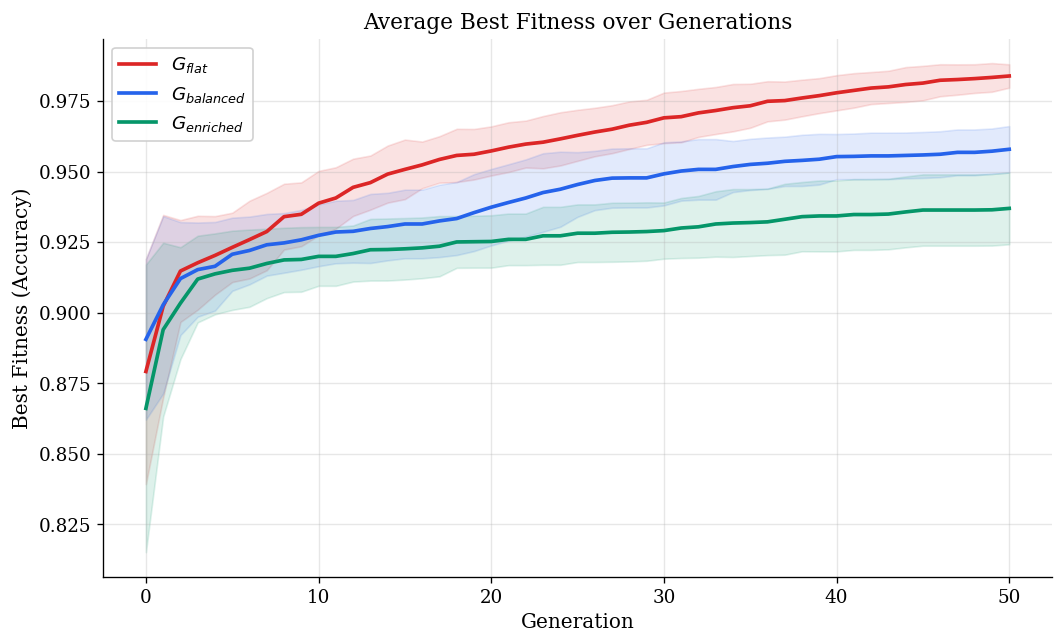

In [32]:
plot_metric('best_fitness', 'Best Fitness (Accuracy)',
           'Average Best Fitness over Generations', 'avg_best_fitness.png')

### 13.2 Average Depth of Best Individual over Generations

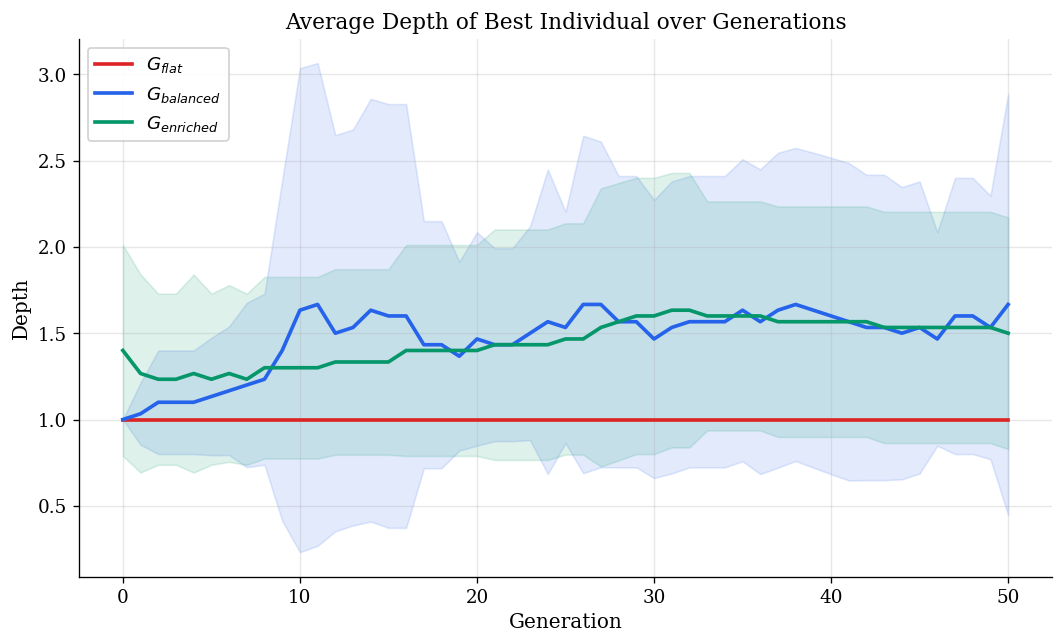

In [33]:
plot_metric('best_depth', 'Depth',
           'Average Depth of Best Individual over Generations', 'avg_best_depth.png')

### 13.3 Average Number of Nodes of Best Individual over Generations

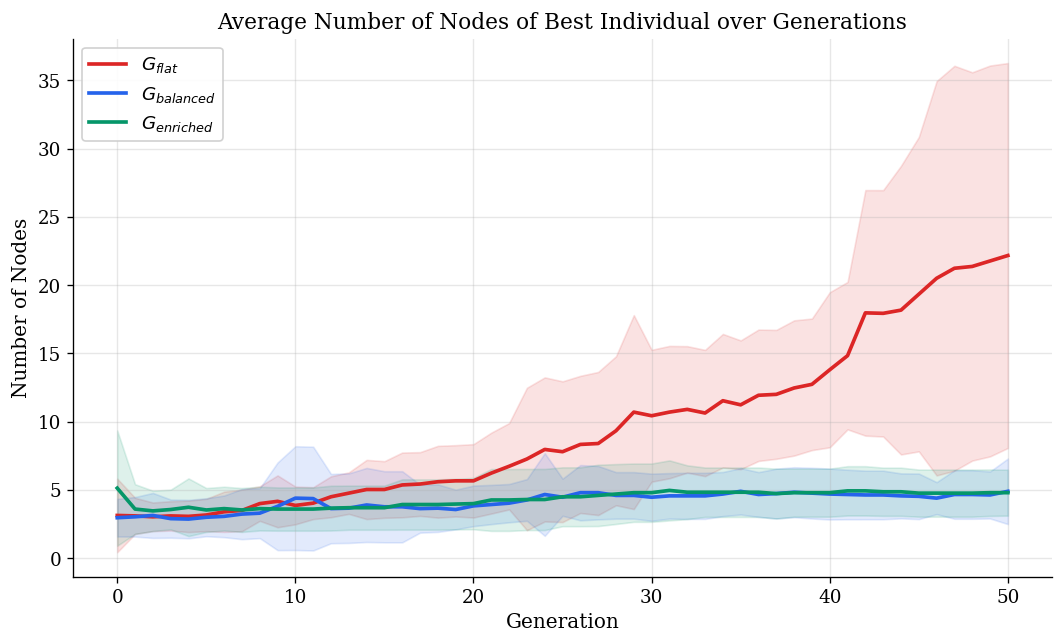

In [34]:
plot_metric('best_nodes', 'Number of Nodes',
           'Average Number of Nodes of Best Individual over Generations', 'avg_best_nodes.png')

### 13.4 Structural Diversity over Generations

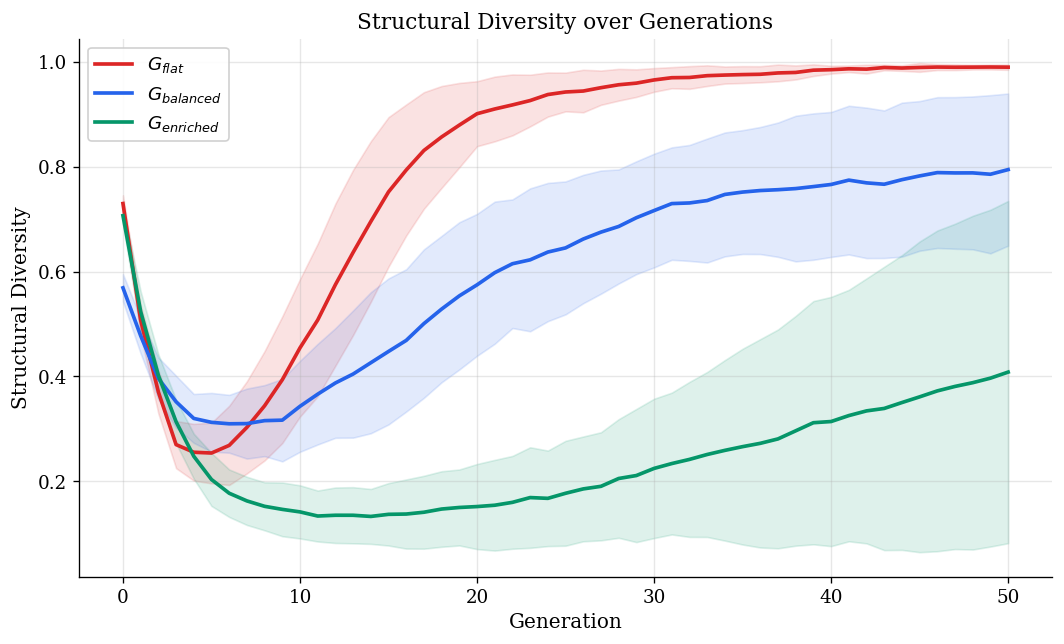

In [35]:
plot_metric('structural_diversity', 'Structural Diversity',
           'Structural Diversity over Generations', 'structural_diversity.png')

### 13.5 Test Fitness — Violin Plots

Test accuracy evaluated **only at the end** of each run.

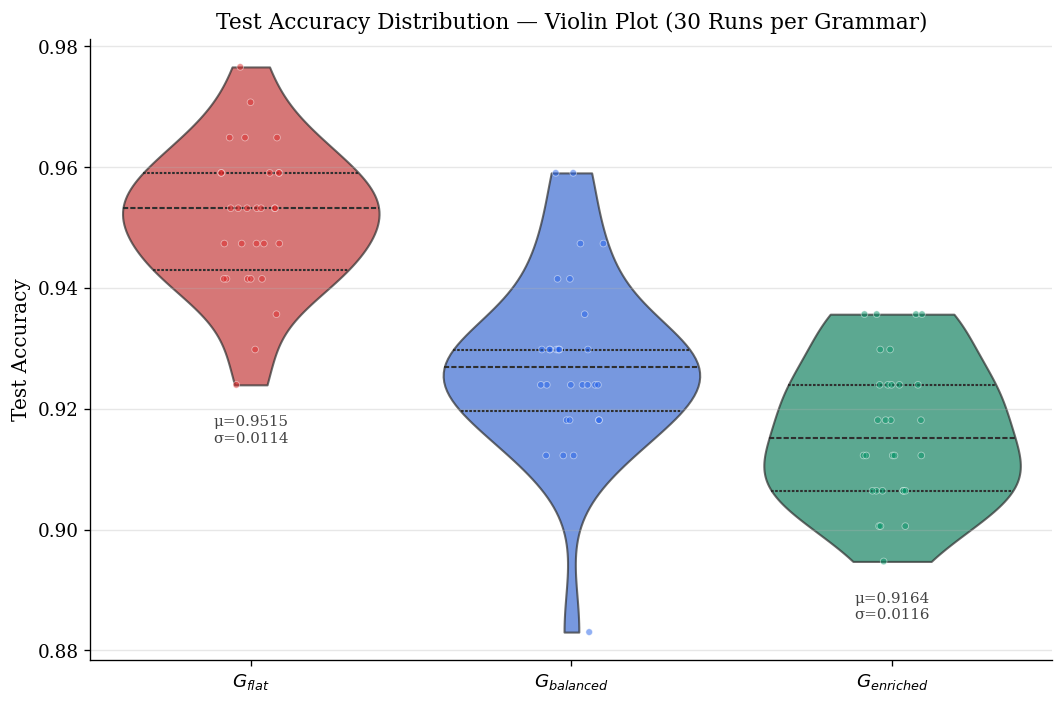

In [36]:
data = []
for gname, results in all_grammar_results.items():
    for r in results:
        data.append({'Grammar': LABELS[gname], 'Test Accuracy': r['test_fitness']})
df = pd.DataFrame(data)

grammar_order = [LABELS[k] for k in ['G_flat', 'G_balanced', 'G_enriched']]
palette = {LABELS[k]: COLORS[k] for k in COLORS}

fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(data=df, x='Grammar', y='Test Accuracy',
               hue='Grammar', order=grammar_order, palette=palette,
               inner='quartile', cut=0, ax=ax, alpha=0.7, legend=False)
sns.stripplot(data=df, x='Grammar', y='Test Accuracy',
              hue='Grammar', order=grammar_order, palette=palette,
              size=4, alpha=0.5, jitter=True, ax=ax,
              edgecolor='white', linewidth=0.5, legend=False)

ax.set_title('Test Accuracy Distribution — Violin Plot (30 Runs per Grammar)')
ax.set_ylabel('Test Accuracy'); ax.set_xlabel('')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for i, gname in enumerate(grammar_order):
    vals = df[df['Grammar'] == gname]['Test Accuracy'].values
    ax.annotate(f'μ={vals.mean():.4f}\nσ={vals.std():.4f}',
                xy=(i, vals.min() - 0.005), ha='center', va='top', fontsize=9, color='#444')

plt.tight_layout()
plt.savefig('plots/test_fitness_violin.png', dpi=200, bbox_inches='tight')
plt.show()

### 13.6 Statistical Significance — Mann-Whitney U Test (Bonferroni)

In [37]:
grammar_names = list(all_grammar_results.keys())
test_fitnesses = {name: [r['test_fitness'] for r in results]
                  for name, results in all_grammar_results.items()}

n_comparisons = len(list(combinations(grammar_names, 2)))
bonferroni_alpha = 0.05 / n_comparisons

print("=" * 70)
print("  Mann-Whitney U Test (Bonferroni-corrected)")
print("=" * 70)
print(f"{'Comparison':<35} {'U stat':>10} {'p-value':>12} {'α_corr':>8} {'Sig?':>8}")
print("-" * 75)

for g1, g2 in combinations(grammar_names, 2):
    u_stat, p_value = stats.mannwhitneyu(
        test_fitnesses[g1], test_fitnesses[g2], alternative='two-sided')
    sig = "YES ***" if p_value < bonferroni_alpha else "no"
    print(f"  {LABELS[g1]} vs {LABELS[g2]:<20} {u_stat:>10.1f} {p_value:>12.6f} {bonferroni_alpha:>8.4f} {sig:>8}")

print()
print(f"{'Grammar':<20} {'Mean':>8} {'Std':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for name in grammar_names:
    vals = np.array(test_fitnesses[name])
    print(f"  {LABELS[name]:<18} {vals.mean():>8.4f} {vals.std():>8.4f} "
          f"{np.median(vals):>8.4f} {vals.min():>8.4f} {vals.max():>8.4f}")

  Mann-Whitney U Test (Bonferroni-corrected)
Comparison                              U stat      p-value   α_corr     Sig?
---------------------------------------------------------------------------
  $G_{flat}$ vs $G_{balanced}$            805.0     0.000000   0.0167  YES ***
  $G_{flat}$ vs $G_{enriched}$            884.5     0.000000   0.0167  YES ***
  $G_{balanced}$ vs $G_{enriched}$            664.0     0.001439   0.0167  YES ***

Grammar                  Mean      Std   Median      Min      Max
------------------------------------------------------------
  $G_{flat}$           0.9515   0.0114   0.9532   0.9240   0.9766
  $G_{balanced}$       0.9277   0.0146   0.9269   0.8830   0.9591
  $G_{enriched}$       0.9164   0.0116   0.9152   0.8947   0.9357


### 13.7 Best Evolved Solutions

In [38]:
for gname, results in all_grammar_results.items():
    sorted_runs = sorted(results, key=lambda r: r['test_fitness'], reverse=True)[:3]
    print(f"\n{'═'*60}")
    print(f"  {LABELS[gname]} — Top 3 solutions by test accuracy")
    print(f"{'═'*60}")
    for rank, r in enumerate(sorted_runs, 1):
        print(f"\n  #{rank}  Test: {r['test_fitness']:.4f}  "
              f"Train: {r['train_fitness']:.4f}  "
              f"Depth: {r['best_depth']}  Nodes: {r['best_nodes']}")
        pheno = r['best_phenotype']
        if pheno and len(pheno) > 100:
            print(f"       {pheno[:100]}...")
        else:
            print(f"       {pheno}")


════════════════════════════════════════════════════════════
  $G_{flat}$ — Top 3 solutions by test accuracy
════════════════════════════════════════════════════════════

  #1  Test: 0.9766  Train: 0.9874  Depth: 1  Nodes: 31
       1.0 - x7 - 1.0 + 0.1 + x19 - x22 - x22 - x20 - x26 - x27 + 0.2 - x13 - x3 - x7 - x1 - x24 - x21 - x2...

  #2  Test: 0.9708  Train: 0.9824  Depth: 1  Nodes: 18
       x19 - x22 - x22 - x27 - x1 - x13 - x24 - 0.2 + 0.5 + x27 - x26 - x27 - x24 * x13 + 0.2 - x2 - x27 - ...

  #3  Test: 0.9649  Train: 0.9874  Depth: 1  Nodes: 19
       0.5 - x23 - 0.5 - 0.1 - x21 - x4 - x22 + 0.1 - 5.0 * x23 - x7 - x26 - x20 + 0.2 - x2 * x14 - 0.2 - x...

════════════════════════════════════════════════════════════
  $G_{balanced}$ — Top 3 solutions by test accuracy
════════════════════════════════════════════════════════════

  #1  Test: 0.9591  Train: 0.9648  Depth: 3  Nodes: 5
       0.2 - ( ( ( x20 * 2.0 ) + x21 ) + x7 )

  #2  Test: 0.9591  Train: 0.9648  Depth: 1  Nodes:

In [39]:
print("\nExperiment complete!")
print(f"Results saved in: {RESULTS_DIR}/")
print(f"Plots saved in:   plots/")
print(f"Total runs: {sum(len(v) for v in all_grammar_results.values())}")


Experiment complete!
Results saved in: results/
Plots saved in:   plots/
Total runs: 90
